# 14 — Dynamic Window Approach (DWA)

**Section:** Motion Planning · **Mirrors MATLAB:** *Path Following with Obstacle Avoidance*

DWA is a **local** planner: at each control step it samples reachable (v, ω) pairs in the dynamic window (limited by current velocity and acceleration), simulates each forward for a short horizon, and scores the resulting trajectory by heading toward the goal, clearance to obstacles, and forward velocity.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

robot = np.array([0., 0., 0., 0., 0.])      # x, y, theta, v, omega
goal  = np.array([10., 10.])
obstacles = np.array([[3, 4], [5, 6], [7, 8], [4, 7], [6, 5], [8, 9]])

v_max, v_min = 1.0, 0.0
w_max, w_min = 1.0, -1.0
a_max, alpha_max = 4.0, 6.0      # window must be larger than discrete step
dt, predict_t = 0.1, 2.5


In [2]:
def predict(state, v, w):
    s = state.copy()
    traj = [s.copy()]
    for _ in range(int(predict_t / dt)):
        s[0] += v * np.cos(s[2]) * dt
        s[1] += v * np.sin(s[2]) * dt
        s[2] += w * dt
        s[3], s[4] = v, w
        traj.append(s.copy())
    return np.array(traj)


def cost(traj, goal, obstacles):
    dx, dy = goal - traj[-1, :2]
    goal_dist    = np.hypot(dx, dy)
    heading_cost = abs(np.arctan2(dy, dx) - traj[-1, 2])
    d = np.min(np.linalg.norm(traj[:, None, :2] - obstacles[None], axis=2), axis=1)
    if d.min() < 0.5:
        return np.inf
    return 1.0 * goal_dist + 0.3 * heading_cost + 0.2 / d.min() + 0.05 * (v_max - traj[-1, 3])


In [3]:
hist = [robot[:2].copy()]
for _ in range(200):
    vs = np.linspace(max(v_min, robot[3] - a_max * dt),
                      min(v_max, robot[3] + a_max * dt), 7)
    ws = np.linspace(max(w_min, robot[4] - alpha_max * dt),
                      min(w_max, robot[4] + alpha_max * dt), 11)
    best_c, best_v, best_w = np.inf, 0.0, 0.0
    for v in vs:
        for w in ws:
            c = cost(predict(robot, v, w), goal, obstacles)
            if c < best_c:
                best_c, best_v, best_w = c, v, w
    robot[0] += best_v * np.cos(robot[2]) * dt
    robot[1] += best_v * np.sin(robot[2]) * dt
    robot[2] += best_w * dt
    robot[3], robot[4] = best_v, best_w
    hist.append(robot[:2].copy())
    if np.linalg.norm(robot[:2] - goal) < 0.3:
        break
hist = np.array(hist)
print(f"Reached goal in {len(hist)} steps. Final distance: {np.linalg.norm(robot[:2] - goal):.3f} m")


Reached goal in 193 steps. Final distance: 0.299 m


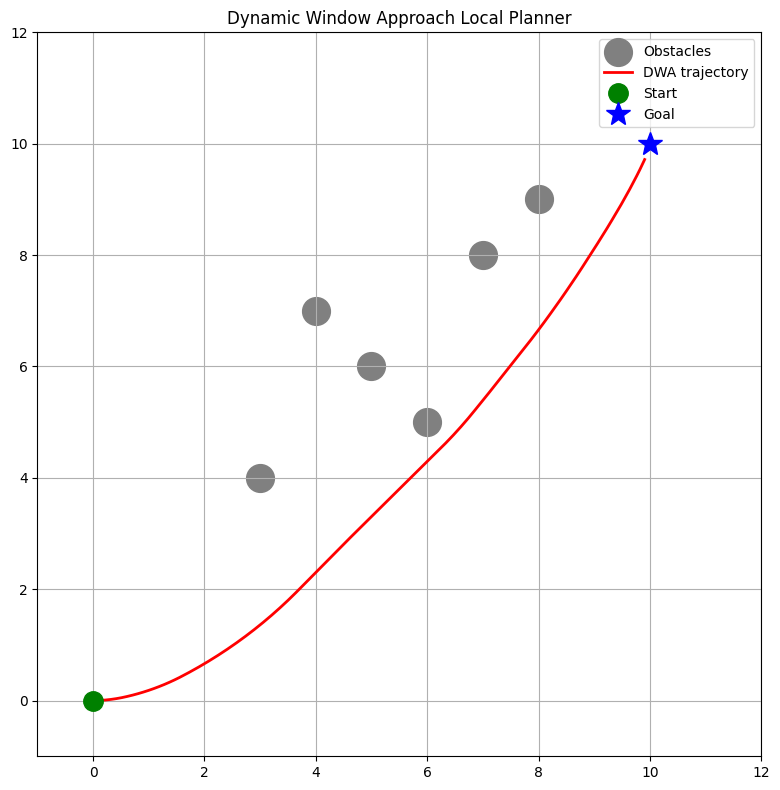

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(obstacles[:, 0], obstacles[:, 1], c='grey', s=400, label='Obstacles')
ax.plot(hist[:, 0], hist[:, 1], 'r-', lw=2, label='DWA trajectory')
ax.plot(0, 0, 'go', ms=14, label='Start')
ax.plot(*goal, 'b*', ms=18, label='Goal')
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_xlim(-1, 12); ax.set_ylim(-1, 12)
ax.set_title('Dynamic Window Approach Local Planner')
plt.tight_layout()
plt.show()
